# Customer Segmentation using K-Means Clustering
### The "Hello World" of Unsupervised Machine Learning

---

## What is Unsupervised Learning?

In **Supervised Learning** (like Iris classification), we have:
- Input features → **Known labels/answers**
- Model learns to predict the label

In **Unsupervised Learning**, we have:
- Input features → **NO labels**
- Model finds hidden patterns on its own!

## Our Goal
Group customers into segments based on their **Annual Income** and **Spending Score** — without telling the model how many types of customers exist!

| Supervised (Iris) | Unsupervised (This Project) |
|---|---|
| Labels given (Setosa, Versicolor...) | No labels given |
| Classification | Clustering |
| Algorithm: Decision Tree, SVM... | Algorithm: K-Means |
| Predict class | Discover groups |


## Step 1: Install & Import Libraries

In [37]:
# Install required libraries
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Create / Load Dataset
We use the classic **Mall Customers Dataset** - a beginner-friendly dataset perfect for clustering.

In [38]:
df = pd.read_csv('https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/mall_customers.csv')

print('Dataset Shape:', df.shape)
print('\n First 5 rows:')
display(df.head())
print('\n Basic Statistics:')
display(df.describe())

Dataset Shape: (200, 5)

 First 5 rows:


,CustomerID,Genre,Age,Annual_Income_k,Spending_Score
0,1,Male,41,18,55
1,2,Female,69,15,25
2,3,Female,28,23,78
3,4,Female,66,22,36
4,5,Male,25,17,69



 Basic Statistics:


,CustomerID,Age,Annual_Income_k,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,45.450000,56.145000,58.435000
std,57.879185,14.616625,26.760317,22.682111
min,1.000000,18.000000,10.000000,5.000000
25%,50.750000,34.750000,27.000000,45.000000
50%,100.500000,46.000000,57.500000,59.000000
75%,150.250000,57.000000,81.000000,77.000000
max,200.000000,69.000000,100.000000,100.000000


## Step 3: Exploratory Data Analysis (EDA)

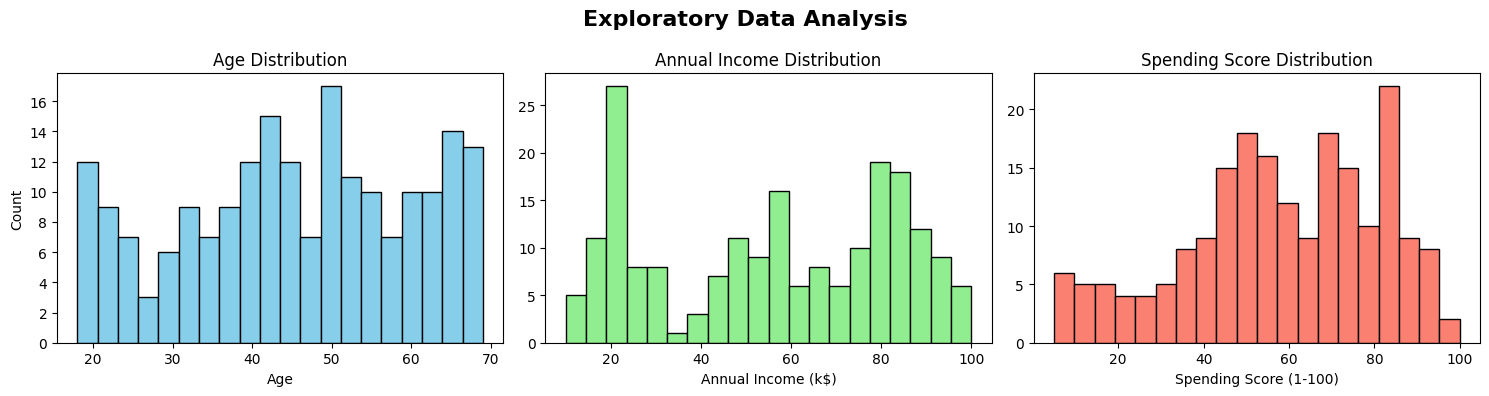

EDA plot saved!


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Age distribution
axes[0].hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Annual Income distribution
axes[1].hist(df['Annual_Income_k'], bins=20, color='lightgreen', edgecolor='black')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')

# Spending Score distribution
axes[2].hist(df['Spending_Score'], bins=20, color='salmon', edgecolor='black')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score (1-100)')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plot saved!')

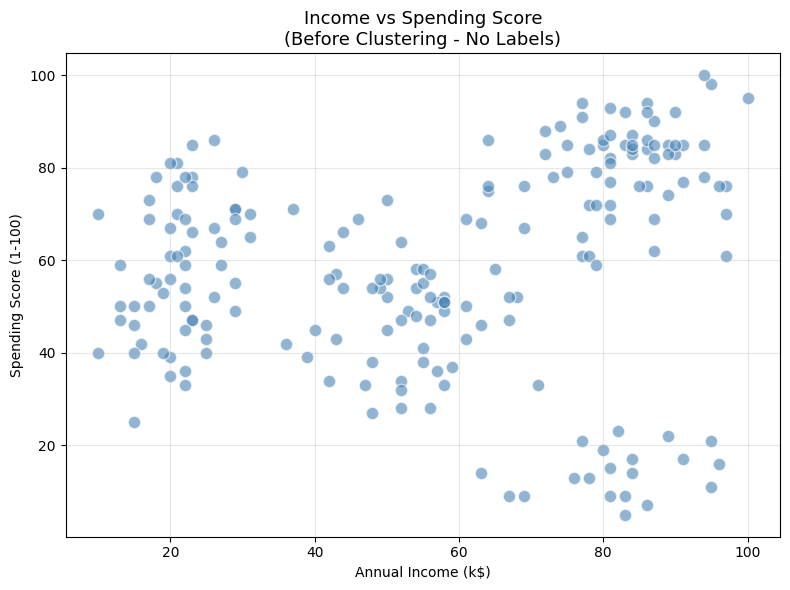

Can YOU see the natural groups? K-Means will find them automatically!


In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual_Income_k'], df['Spending_Score'],
            alpha=0.6, c='steelblue', edgecolors='white', s=80)
plt.title('Income vs Spending Score\n(Before Clustering - No Labels)', fontsize=13)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('before_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Can YOU see the natural groups? K-Means will find them automatically!')

## Step 4: Feature Selection & Preprocessing
We use **Annual Income** and **Spending Score** — the two most informative features for customer segmentation.

In [41]:
# Select features for clustering
X = df[['Annual_Income_k', 'Spending_Score']].values
print('Features selected:', ['Annual_Income_k', 'Spending_Score'])
print('Shape of X:', X.shape)

# Scale the features (important for distance-based algorithms!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\n StandardScaler Applied:')
print(f'   Original Income range: {X[:,0].min():.0f} - {X[:,0].max():.0f}')
print(f'   Scaled Income range:   {X_scaled[:,0].min():.2f} - {X_scaled[:,0].max():.2f}')
print('\n Why Scaling? K-Means uses distances — unscaled features with larger values would dominate!')

Features selected: ['Annual_Income_k', 'Spending_Score']
Shape of X: (200, 2)

 StandardScaler Applied:
   Original Income range: 10 - 100
   Scaled Income range:   -1.73 - 1.64

 Why Scaling? K-Means uses distances — unscaled features with larger values would dominate!


## Step 5: Find Optimal K - The Elbow Method
**The big question in K-Means: How many clusters (K) should we choose?**

The **Elbow Method** plots inertia (within-cluster sum of squares) for different K values. We pick the "elbow" point!

K=2: Inertia=212.43, Silhouette=0.472
K=3: Inertia=105.62, Silhouette=0.524
K=4: Inertia=66.22, Silhouette=0.528
K=5: Inertia=46.30, Silhouette=0.551
K=6: Inertia=37.72, Silhouette=0.472
K=7: Inertia=30.68, Silhouette=0.457
K=8: Inertia=27.43, Silhouette=0.473
K=9: Inertia=24.30, Silhouette=0.445
K=10: Inertia=22.20, Silhouette=0.406


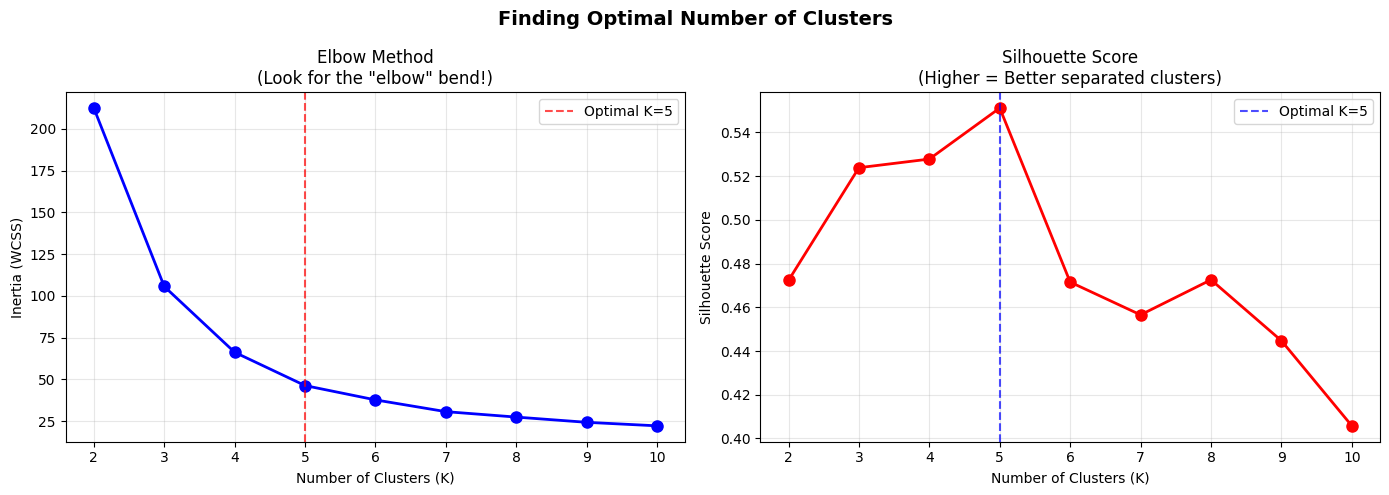


 Based on Elbow + Silhouette: Optimal K = 5


In [42]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(sil)
    print(f'K={k}: Inertia={km.inertia_:.2f}, Silhouette={sil:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method\n(Look for the "elbow" bend!)', fontsize=12)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Optimal K=5')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score\n(Higher = Better separated clusters)', fontsize=12)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=5, color='blue', linestyle='--', alpha=0.7, label='Optimal K=5')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Finding Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Based on Elbow + Silhouette: Optimal K = 5')

## Step 6: Train the K-Means Model (K=5)

In [43]:
# Train final K-Means model
OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Assign cluster labels
df['Cluster'] = kmeans.labels_

print('K-Means model trained!')
print(f'\n Cluster Distribution:')
print(df['Cluster'].value_counts().sort_index())

print(f'\n Cluster Centers (in original scale):')
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
for i, center in enumerate(centers_original):
    print(f'   Cluster {i}: Income={center[0]:.1f}k, Spending Score={center[1]:.1f}')

K-Means model trained!

 Cluster Distribution:
Cluster
0    31
1    66
2    49
3    20
4    34
Name: count, dtype: int64

 Cluster Centers (in original scale):
   Cluster 0: Income=20.2k, Spending Score=45.9
   Cluster 1: Income=82.4k, Spending Score=80.4
   Cluster 2: Income=53.8k, Spending Score=46.4
   Cluster 3: Income=82.0k, Spending Score=14.2
   Cluster 4: Income=26.2k, Spending Score=70.7


## Step 7: Visualize the Clusters

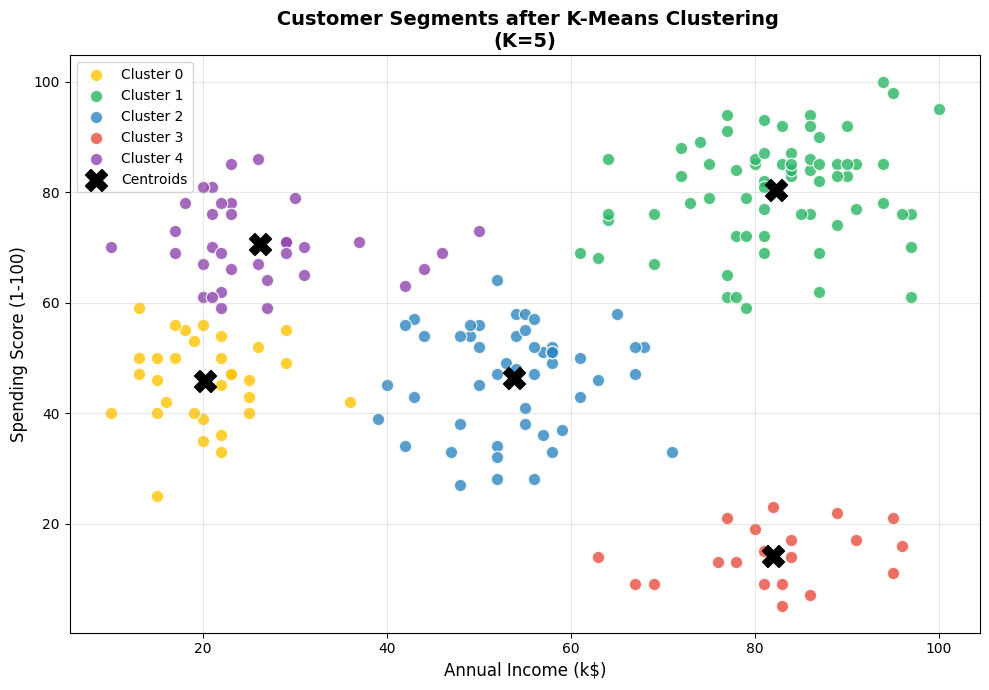

Cluster visualization saved!


In [44]:
# Cluster names based on business interpretation
cluster_names = {
    0: ' Average Customers',
    1: ' High Income, High Spend (VIP)',
    2: ' Low Income, High Spend (Impulsive)',
    3: ' High Income, Low Spend (Careful)',
    4: ' Low Income, Low Spend (Budget)'
}

# Assign names by sorting cluster centers (income, spending)
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
center_df = pd.DataFrame(centers_original, columns=['Income', 'Spending'])
center_df['Cluster'] = range(OPTIMAL_K)

colors = ['#FFC300', '#28B463', '#2E86C1', '#E74C3C', '#8E44AD']

plt.figure(figsize=(10, 7))

for i in range(OPTIMAL_K):
    mask = df['Cluster'] == i
    plt.scatter(df[mask]['Annual_Income_k'], df[mask]['Spending_Score'],
                c=colors[i], label=f'Cluster {i}', s=80, alpha=0.8, edgecolors='white')

# Plot cluster centers
plt.scatter(centers_original[:, 0], centers_original[:, 1],
            c='black', marker='X', s=250, zorder=5, label='Centroids')

plt.title(' Customer Segments after K-Means Clustering\n(K=5)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cluster visualization saved!')

In [45]:
# Cluster-wise analysis
print('Cluster-wise Statistics:\n')
analysis = df.groupby('Cluster').agg({
    'Annual_Income_k': ['mean', 'min', 'max'],
    'Spending_Score': ['mean', 'min', 'max'],
    'Age': 'mean',
    'CustomerID': 'count'
}).round(1)
analysis.columns = ['Avg Income', 'Min Income', 'Max Income',
                     'Avg Spending', 'Min Spending', 'Max Spending',
                     'Avg Age', 'Count']
display(analysis)

print('\n Business Interpretation:')
print('   Cluster with HIGH income + HIGH spending → VIP / Loyal Customers')
print('   Cluster with LOW income + HIGH spending  → Impulsive Buyers')
print('   Cluster with HIGH income + LOW spending  → Careful/Conservative Customers')
print('   Cluster with LOW income + LOW spending   → Budget Shoppers')
print('   Middle cluster                           → Average / Standard Customers')

Cluster-wise Statistics:



,Avg Income,Min Income,Max Income,Avg Spending,Min Spending,Max Spending,Avg Age,Count
Cluster,,,,,,,,
0,20.2,10,36,45.9,25,59,48.7,31
1,82.4,61,100,80.4,59,100,45.3,66
2,53.8,39,71,46.4,27,64,47.7,49
3,82.0,63,96,14.2,5,23,43.4,20
4,26.2,10,50,70.7,59,86,40.8,34



 Business Interpretation:
   Cluster with HIGH income + HIGH spending → VIP / Loyal Customers
   Cluster with LOW income + HIGH spending  → Impulsive Buyers
   Cluster with HIGH income + LOW spending  → Careful/Conservative Customers
   Cluster with LOW income + LOW spending   → Budget Shoppers
   Middle cluster                           → Average / Standard Customers


## Step 8: Save the Model for Flask Deployment

In [46]:
# Save the trained model and scaler
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(' Model saved as: kmeans_model.pkl')
print(' Scaler saved as: scaler.pkl')
print('\n Download these files for Flask deployment!')
print('   → Place them in the model/ folder of the Flask project')

# Test the saved model
print('\n Testing saved model...')
loaded_model = joblib.load('kmeans_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

test_customer = np.array([[65, 80]])  # Income=65k, Spending=80
test_scaled = loaded_scaler.transform(test_customer)
cluster = loaded_model.predict(test_scaled)[0]
print(f'   Test Customer (Income=65k, Spending=80) → Cluster {cluster}')
print('Model works correctly!')

 Model saved as: kmeans_model.pkl
 Scaler saved as: scaler.pkl

 Download these files for Flask deployment!
   → Place them in the model/ folder of the Flask project

 Testing saved model...
   Test Customer (Income=65k, Spending=80) → Cluster 1
Model works correctly!


## **Summary**

| Step | What we did |
|------|-------------|
| 1 | Loaded Mall Customers dataset |
| 2 | Explored data (EDA) |
| 3 | Selected & Scaled features |
| 4 | Used Elbow Method to find K=5 |
| 5 | Trained K-Means with K=5 |
| 6 | Visualized 5 customer segments |
| 7 | Saved model + scaler for deployment |

### **Key Takeaways**
- **Unsupervised learning** finds patterns without labels
- **K-Means** groups data by minimizing within-cluster distances
- **Elbow Method** + **Silhouette Score** help choose K
- **Always scale** features before clustering!
- The model can predict the segment for any **new customer**

### **Next Steps**
- Deploy using Flask (see the Flask project folder!)
- Try with 3 features (Age + Income + Spending)
- Explore other algorithms: DBSCAN, Hierarchical Clustering
